In [1]:
import os
import sys
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.collections import LineCollection
from scipy.ndimage import gaussian_filter1d
from matplotlib import gridspec
 
# Add parent directory to sys.path
parent_dir = os.path.abspath(os.path.join(os.getcwd(), '..'))
if parent_dir not in sys.path:
    sys.path.insert(0, parent_dir)

work_path = "M:/1confiProj/"
os.chdir(work_path)
#from scripts.experiments import ModelEvaluator
from utils.plot_function import *
raw_data_path = 'P:/3026008.02/rawData/'
data_path = 'P:/3026008.02/AllData/'
sub_lst = [2, 3, 5, 6 ,11 ,15 ,20, 25]

## Data Preparation

In [2]:
#data preparation
df = pd.DataFrame()
for sub_id in sub_lst:
    subA_data = pd.read_excel(os.path.join(raw_data_path, 'Subj_' + str(sub_id) + '_BimodalAuditoryData_Excel.xlsx'))
    subV_data = pd.read_excel(os.path.join(raw_data_path, 'Subj_' + str(sub_id) + '_BimodalVisualData_Excel.xlsx'))
    subA_data.loc[:,'sub_id'] = sub_id
    subA_data.loc[:,'Modality'] = 'A'
    subV_data.loc[:,'sub_id'] = sub_id
    subV_data.loc[:,'Modality'] = 'V'
    subV_data.loc[:,'stim_loc'] = subV_data['Vis Loc']
    subA_data.loc[:,'stim_loc'] = subA_data['Aud Loc']

    # concatenate the data
    df = pd.concat([df, subA_data, subV_data], ignore_index=True)

In [5]:
# deal with outliers for auditory, visual and two reliability levels separately
def remove_outliers(df,bias_col='bias'):
    df = df.copy()
    df.loc[:,'bias_zscore'] = (df[bias_col] - df[bias_col].mean()) / df[bias_col].std()
    df.loc[:,'CISize_zscore'] = (df['CI Size'] - df['CI Size'].mean()) / df['CI Size'].std()
    return df[(df.bias_zscore.abs() <= 3) & (df.CISize_zscore.abs() <= 3)]

def get_cirange(df):
    # ci range
    ci_bins = np.append(0, np.linspace(df['CI Size'].quantile(0.05), df['CI Size'].quantile(0.95), 11))  # 10 bins
    ci_bins = np.append(ci_bins, df['CI Size'].max()+0.1)  # ensure the max value is included
    df['CI Bin'] = pd.cut(df['CI Size'], bins=ci_bins, labels=False)
    ci_labels = [(ci_bins[i] + ci_bins[i+1]) / 2 for i in range(len(ci_bins)-1)]
    return df.copy(), ci_labels

###  Bi-modal Trials data prepare

In [4]:
df_bi = df.loc[(~df['Vis Loc'].isna())&(~df['Aud Loc'].isna())].copy().reset_index(drop=True)
# get the perceptual bias for bi-modal congruent trials
df_bi_stat = df_bi.loc[df_bi['Aud Loc'] == df_bi['Vis Loc']].groupby(['sub_id', 'Modality', 'Vis Rel', 'stim_loc'])['Resp Loc'].agg(['mean', 'std']).reset_index()
df_bi = df_bi.merge(df_bi_stat, how='left', on=['sub_id', 'Modality', 'Vis Rel', 'stim_loc'])
df_bi['bias'] = df_bi['Resp Loc'] - df_bi['mean']

#flip bias
df_bi['delta_VA'] = df_bi['Vis Loc'] - df_bi['Aud Loc']
df_bi['flipBias'] = df_bi['bias'].copy()
df_bi.loc[df_bi['delta_VA']<0, 'flipBias'] = -df_bi.loc[df_bi['delta_VA']<0, 'flipBias']
df_bi['abs_delta_VA'] = df_bi.delta_VA.abs()

df_bi_filter = (df_bi.groupby(['sub_id', 'Modality', 'Vis Rel', 'Vis Loc', 'Aud Loc'], group_keys=False)
                 .apply(remove_outliers)
                 .reset_index(drop=True))

C:\Users\wenlou\AppData\Local\Temp\ipykernel_4116\1860239414.py:14: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(remove_outliers)


# Incongruent trials

In [5]:
df_incong = df_bi_filter.loc[df_bi_filter['Aud Loc'] != df_bi_filter['Vis Loc']].copy().reset_index(drop=True)
df_incong, ci_labels= get_cirange(df_incong)
df_incong.head()

,Block Nr,Trial Nr,Aud Loc,Vis Loc,Vis Rel,Resp Loc,CI Size,Sources,Conf Level,sub_id,...,stim_loc,mean,std,bias,delta_VA,flipBias,abs_delta_VA,bias_zscore,CISize_zscore,CI Bin
0,1,4,-5.0,-10.0,1,-5.94,5.56,1.0,39.0,2,...,-5,-4.934054,0.935258,-1.005946,-5.0,1.005946,5.0,1.339457,0.379960,4
1,1,87,-5.0,-10.0,1,-7.05,3.32,2.0,80.0,2,...,-5,-4.934054,0.935258,-2.115946,-5.0,2.115946,5.0,0.383732,-1.438233,1
2,1,141,-5.0,-10.0,1,-6.27,4.66,1.0,47.0,2,...,-5,-4.934054,0.935258,-1.335946,-5.0,1.335946,5.0,1.055323,-0.350564,3
3,2,1,-5.0,-10.0,1,-9.03,4.83,1.0,69.0,2,...,-5,-4.934054,0.935258,-4.095946,-5.0,4.095946,5.0,-1.321073,-0.212576,3
4,2,101,-5.0,-10.0,1,-9.69,6.12,1.0,69.0,2,...,-5,-4.934054,0.935258,-4.755946,-5.0,4.755946,5.0,-1.889341,0.834509,4


In [9]:
# two step average:
# sources and the causal coonfidence
df_incong_avg = df_incong.groupby(['sub_id', 'Modality', 'Vis Rel', 'abs_delta_VA', 'stim_loc','Sources', 'CI Bin'], as_index=False).agg({'flipBias':['mean', 'count'], 'Conf Level':'mean'}).reset_index()
df_incong_avg.columns = ['_'.join(col).strip() if col[1] else col[0] for col in df_incong_avg.columns.values]

df_incong_avg = df_incong_avg.groupby(['sub_id', 'Modality', 'Vis Rel', 'abs_delta_VA', 'Sources', 'CI Bin'], as_index=False).agg({'flipBias_mean':'mean', 'flipBias_count':'sum', 'Conf Level_mean':'mean'}).reset_index()
df_incong_avg.head()

,index,sub_id,Modality,Vis Rel,abs_delta_VA,Sources,CI Bin,flipBias_mean,flipBias_count,Conf Level_mean
0,0,2,A,1,5.0,1.0,0,4.295024,22,59.503175
1,1,2,A,1,5.0,1.0,1,3.956596,31,64.616667
2,2,2,A,1,5.0,1.0,2,3.672081,47,67.172511
3,3,2,A,1,5.0,1.0,3,3.340594,50,52.441404
4,4,2,A,1,5.0,1.0,4,2.818587,26,55.248571


In [ ]:
# two step average:
# # sources and the causal confidence
# df_incong_avg = df_incong.groupby(['sub_id', 'Modality', 'Vis Rel', 'abs_delta_VA', 'stim_loc','Sources', 'CI Bin'], as_index=False).agg({'flipBias':['mean', 'count'], 'Conf Level':'mean'}).reset_index()
# df_incong_avg.columns = ['_'.join(col).strip() if col[1] else col[0] for col in df_incong_avg.columns.values]
# df_incong_avg = df_incong_avg.groupby(['sub_id', 'Modality', 'Vis Rel', 'abs_delta_VA', 'Sources', 'CI Bin'], as_index=False).agg({'flipBias_mean':'mean', 'flipBias_count':'sum', 'Conf Level_mean':'mean'}).reset_index()
# # select the delta_VA >0
# #df_incong_avg = df_incong_avg.loc[df_incong_avg['delta_VA']>0].copy().reset_index(drop=True)
# average the stims
df_incong_avg_stim = df_incong_avg.groupby(['sub_id', 'Modality', 'Vis Rel', 'Sources', 'CI Bin']).agg({'flipBias_mean':'mean', 'flipBias_count':'sum', 'Conf Level_mean':'mean'}).reset_index()

# normalize the count to percentage
sum_count = df_incong_avg_stim.groupby(['Modality', 'Vis Rel'], as_index=False)['flipBias_count'].sum()
df_incong_avg_stim = pd.merge(df_incong_avg_stim, sum_count, on=['Modality', 'Vis Rel'], suffixes=('', '_total'))
df_incong_avg_stim['count_reg'] = df_incong_avg_stim['flipBias_count'] / df_incong_avg_stim['flipBias_count_total']   # convert to percentage
df_incong_avg_stim['vislab'] = df_incong_avg_stim['Vis Rel'].map({1:'High', 2:'Low'})

In [17]:
df_incong_avg_stim

,sub_id,Modality,Vis Rel,Sources,CI Bin,flipBias_mean,flipBias_count,Conf Level_mean,flipBias_count_total,count_reg,vislab
0,2,A,1,1.0,0,6.520282,27,67.251587,5676,0.004757,High
1,2,A,1,1.0,1,10.452220,45,48.818750,5676,0.007928,High
2,2,A,1,1.0,2,8.109202,82,56.946392,5676,0.014447,High
3,2,A,1,1.0,3,9.325332,98,46.977018,5676,0.017266,High
4,2,A,1,1.0,4,7.546742,55,52.471339,5676,0.009690,High
...,...,...,...,...,...,...,...,...,...,...,...
562,25,V,2,2.0,7,-0.259063,19,61.972222,1917,0.009911,Low
563,25,V,2,2.0,8,0.872361,8,36.555556,1917,0.004173,Low
564,25,V,2,2.0,9,-0.083958,11,66.250000,1917,0.005738,Low
565,25,V,2,2.0,10,-0.618437,16,68.291667,1917,0.008346,Low


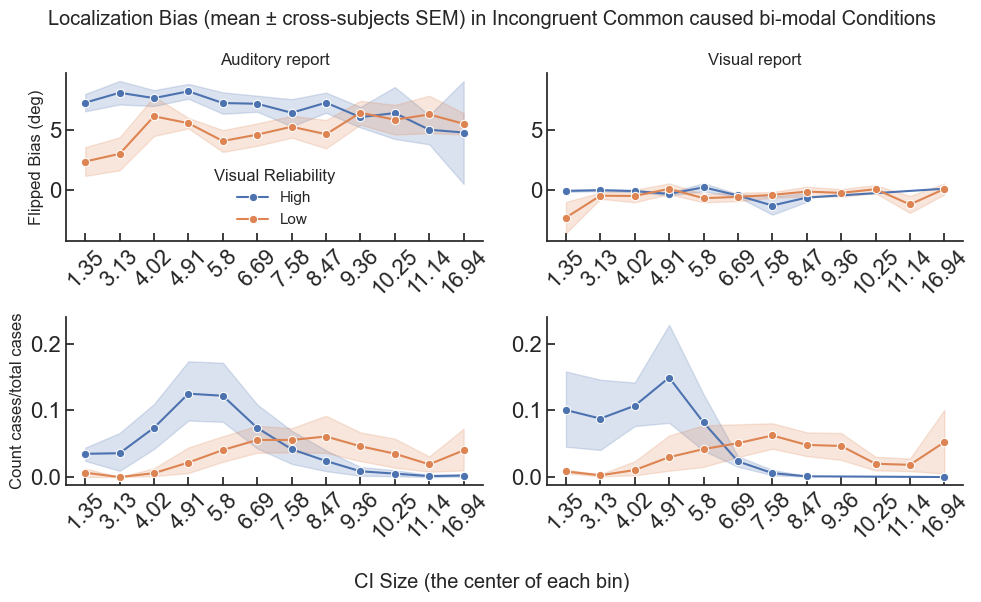

In [13]:
#plot
fig, axs = plt.subplots(2, 2, figsize=(10, 6))
# share y-axis within each row manually
for row in axs:
    row[1].sharey(row[0])  # share y between left and right subplot in the same row

# auditory
sns.lineplot(data=df_incong_avg_stim[(df_incong_avg_stim['Modality']=='A')&(df_incong_avg_stim['Sources']==1)], x='CI Bin', y='flipBias_mean', hue='vislab', errorbar='se', marker='o', ax = axs[0, 0])
# visual
sns.lineplot(data=df_incong_avg_stim[(df_incong_avg_stim['Modality']=='V')&(df_incong_avg_stim['Sources']==1)], x='CI Bin', y='flipBias_mean', hue='vislab', errorbar='se', marker='o', ax = axs[0, 1],legend=None)
# auditory
sns.lineplot(data=df_incong_avg_stim[(df_incong_avg_stim['Modality']=='A')&(df_incong_avg_stim['Sources']==1)], x='CI Bin', hue='vislab', y='count_reg', estimator='sum', marker='o', ax = axs[1,0],legend=None)
# visual
sns.lineplot(data=df_incong_avg_stim[(df_incong_avg_stim['Modality']=='V')&(df_incong_avg_stim['Sources']==1)], x='CI Bin', y='count_reg', hue='vislab', estimator='sum', marker='o', ax = axs[1,1],legend=None)

for ax in axs.flatten():
    clean_axs(ax)
    ax.set_xticks(range(len(ci_labels)))
    ax.set_xticklabels([round(x, 2) for x in ci_labels], rotation=45)
    ax.set_xlabel('')
    ax.set_ylabel('')
    #ax.legend('')
fig.supxlabel('CI Size (the center of each bin)')
axs[0,0].set_title('Auditory report')
axs[0,0].set_ylabel('Flipped Bias (deg)')
axs[0,1].set_title('Visual report')
axs[1,0].set_ylabel('Count cases/total cases')
axs[0,0].legend(title='Visual Reliability', frameon=False)
#axs[1].legend(title='Visual Reliability', frameon=False)
fig.suptitle('Localization Bias (mean ± cross-subjects SEM) in Incongruent Common caused bi-modal Conditions')
plt.tight_layout()
plt.show()

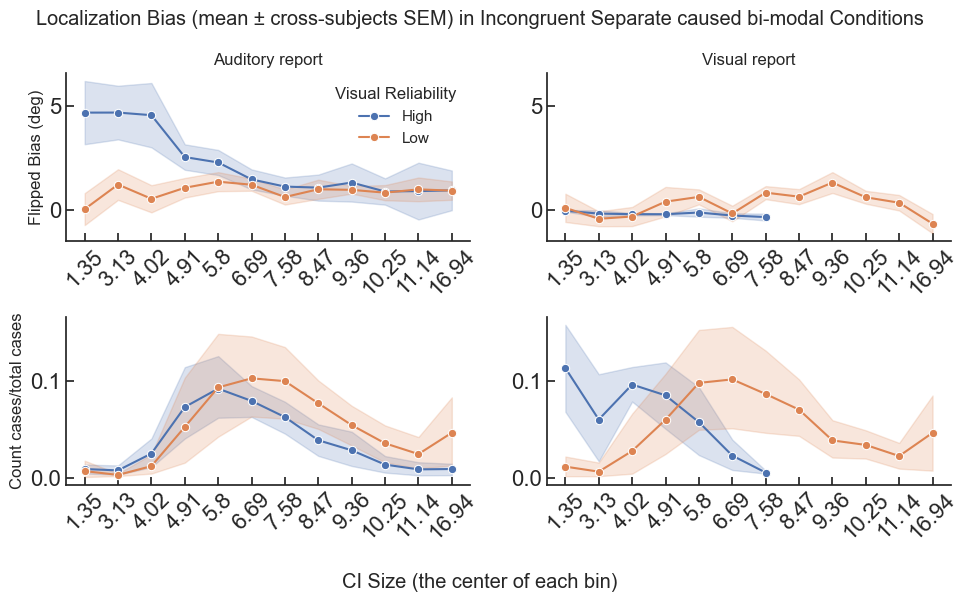

In [14]:
#plot
fig, axs = plt.subplots(2, 2, figsize=(10, 6))
# share y-axis within each row manually
for row in axs:
    row[1].sharey(row[0])  # share y between left and right subplot in the same row

# auditory
sns.lineplot(data=df_incong_avg_stim[(df_incong_avg_stim['Modality']=='A')&(df_incong_avg_stim['Sources']==2)], x='CI Bin', y='flipBias_mean', hue='vislab', errorbar='se', marker='o', ax = axs[0, 0])
# visual
sns.lineplot(data=df_incong_avg_stim[(df_incong_avg_stim['Modality']=='V')&(df_incong_avg_stim['Sources']==2)], x='CI Bin', y='flipBias_mean', hue='vislab', errorbar='se', marker='o', ax = axs[0, 1],legend=None)
# auditory
sns.lineplot(data=df_incong_avg_stim[(df_incong_avg_stim['Modality']=='A')&(df_incong_avg_stim['Sources']==2)], x='CI Bin', hue='vislab', y='count_reg', estimator='sum', marker='o', ax = axs[1,0],legend=None)
# visual
sns.lineplot(data=df_incong_avg_stim[(df_incong_avg_stim['Modality']=='V')&(df_incong_avg_stim['Sources']==2)], x='CI Bin', y='count_reg', hue='vislab', estimator='sum', marker='o', ax = axs[1,1],legend=None)

for ax in axs.flatten():
    clean_axs(ax)
    ax.set_xticks(range(len(ci_labels)))
    ax.set_xticklabels([round(x, 2) for x in ci_labels], rotation=45)
    ax.set_xlabel('')
    ax.set_ylabel('')
    #ax.legend('')
fig.supxlabel('CI Size (the center of each bin)')
axs[0,0].set_title('Auditory report')
axs[0,0].set_ylabel('Flipped Bias (deg)')
axs[0,1].set_title('Visual report')
axs[1,0].set_ylabel('Count cases/total cases')
axs[0,0].legend(title='Visual Reliability', frameon=False)
#axs[1].legend(title='Visual Reliability', frameon=False)
fig.suptitle('Localization Bias (mean ± cross-subjects SEM) in Incongruent Separate caused bi-modal Conditions')
plt.tight_layout()
plt.show()

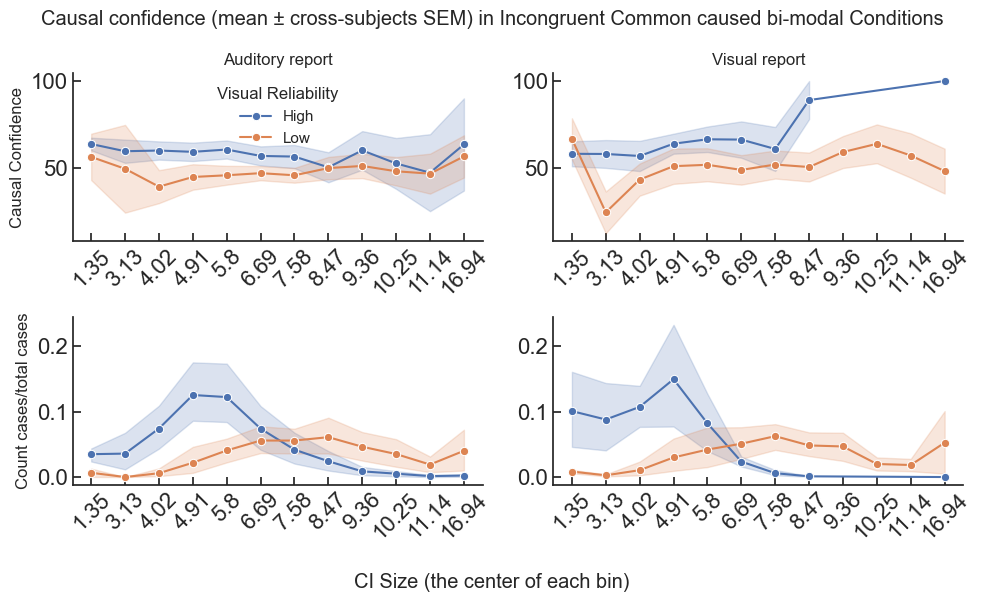

In [15]:
#plot
fig, axs = plt.subplots(2, 2, figsize=(10, 6))
# share y-axis within each row manually
for row in axs:
    row[1].sharey(row[0])  # share y between left and right subplot in the same row

# auditory
sns.lineplot(data=df_incong_avg_stim[(df_incong_avg_stim['Modality']=='A')&(df_incong_avg_stim['Sources']==1)], x='CI Bin', y='Conf Level_mean', hue='vislab', errorbar='se', marker='o', ax = axs[0, 0])
# visual
sns.lineplot(data=df_incong_avg_stim[(df_incong_avg_stim['Modality']=='V')&(df_incong_avg_stim['Sources']==1)], x='CI Bin', y='Conf Level_mean', hue='vislab', errorbar='se', marker='o', ax = axs[0, 1],legend=None)
# auditory
sns.lineplot(data=df_incong_avg_stim[(df_incong_avg_stim['Modality']=='A')&(df_incong_avg_stim['Sources']==1)], x='CI Bin', hue='vislab', y='count_reg', estimator='sum', marker='o', ax = axs[1,0],legend=None)
# visual
sns.lineplot(data=df_incong_avg_stim[(df_incong_avg_stim['Modality']=='V')&(df_incong_avg_stim['Sources']==1)], x='CI Bin', y='count_reg', hue='vislab', estimator='sum', marker='o', ax = axs[1,1],legend=None)

for ax in axs.flatten():
    clean_axs(ax)
    ax.set_xticks(range(len(ci_labels)))
    ax.set_xticklabels([round(x, 2) for x in ci_labels], rotation=45)
    ax.set_xlabel('')
    ax.set_ylabel('')
    #ax.legend('')
fig.supxlabel('CI Size (the center of each bin)')
axs[0,0].set_title('Auditory report')
axs[0,0].set_ylabel('Causal Confidence')
axs[0,1].set_title('Visual report')
axs[1,0].set_ylabel('Count cases/total cases')
axs[0,0].legend(title='Visual Reliability', frameon=False)
#axs[1].legend(title='Visual Reliability', frameon=False)
fig.suptitle('Causal confidence (mean ± cross-subjects SEM) in Incongruent Common caused bi-modal Conditions')
plt.tight_layout()
plt.show()

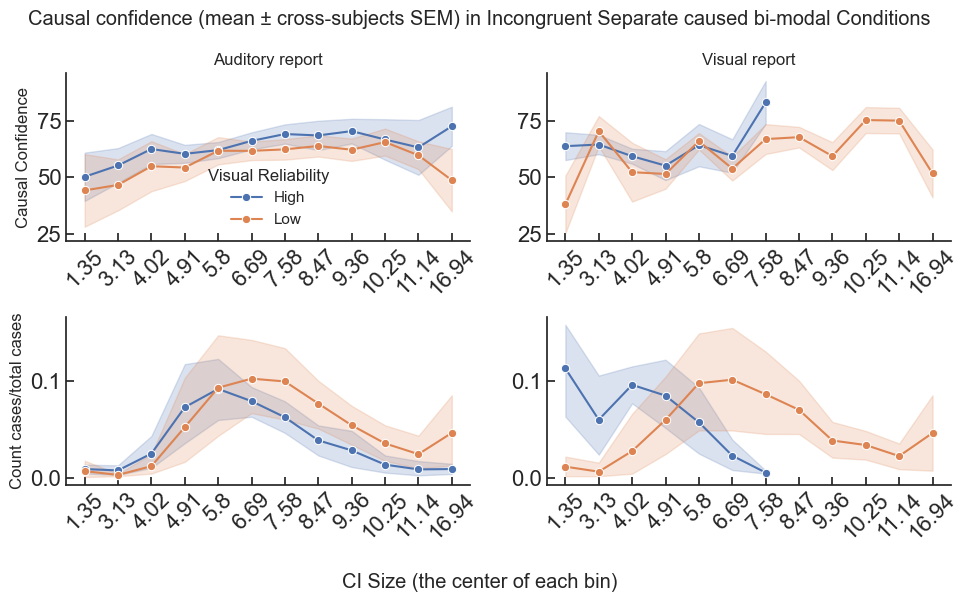

In [16]:
#plot
fig, axs = plt.subplots(2, 2, figsize=(10, 6))
# share y-axis within each row manually
for row in axs:
    row[1].sharey(row[0])  # share y between left and right subplot in the same row

# auditory
sns.lineplot(data=df_incong_avg_stim[(df_incong_avg_stim['Modality']=='A')&(df_incong_avg_stim['Sources']==2)], x='CI Bin', y='Conf Level_mean', hue='vislab', errorbar='se', marker='o', ax = axs[0, 0])
# visual
sns.lineplot(data=df_incong_avg_stim[(df_incong_avg_stim['Modality']=='V')&(df_incong_avg_stim['Sources']==2)], x='CI Bin', y='Conf Level_mean', hue='vislab', errorbar='se', marker='o', ax = axs[0, 1],legend=None)
# auditory
sns.lineplot(data=df_incong_avg_stim[(df_incong_avg_stim['Modality']=='A')&(df_incong_avg_stim['Sources']==2)], x='CI Bin', hue='vislab', y='count_reg', estimator='sum', marker='o', ax = axs[1,0],legend=None)
# visual
sns.lineplot(data=df_incong_avg_stim[(df_incong_avg_stim['Modality']=='V')&(df_incong_avg_stim['Sources']==2)], x='CI Bin', y='count_reg', hue='vislab', estimator='sum', marker='o', ax = axs[1,1],legend=None)

for ax in axs.flatten():
    clean_axs(ax)
    ax.set_xticks(range(len(ci_labels)))
    ax.set_xticklabels([round(x, 2) for x in ci_labels], rotation=45)
    ax.set_xlabel('')
    ax.set_ylabel('')
    #ax.legend('')
fig.supxlabel('CI Size (the center of each bin)')
axs[0,0].set_title('Auditory report')
axs[0,0].set_ylabel('Causal Confidence')
axs[0,1].set_title('Visual report')
axs[1,0].set_ylabel('Count cases/total cases')
axs[0,0].legend(title='Visual Reliability', frameon=False)
#axs[1].legend(title='Visual Reliability', frameon=False)
fig.suptitle('Causal confidence (mean ± cross-subjects SEM) in Incongruent Separate caused bi-modal Conditions')
plt.tight_layout()
plt.show()

## Congruent trials

In [18]:
df_cong = df_bi_filter.loc[df_bi_filter['Aud Loc'] == df_bi_filter['Vis Loc']].copy().reset_index(drop=True)
df_cong, ci_labels= get_cirange(df_cong)
df_cong['flipBias'] = df_cong['flipBias'].abs() # congruent trials, direction of biases is meaningless.
df_cong.head()

,Block Nr,Trial Nr,Aud Loc,Vis Loc,Vis Rel,Resp Loc,CI Size,Sources,Conf Level,sub_id,...,stim_loc,mean,std,bias,delta_VA,flipBias,abs_delta_VA,bias_zscore,CISize_zscore,CI Bin
0,1,16,-10.0,-10.0,1,-7.93,3.53,1.0,80.0,2,...,-10,-8.312162,1.111541,0.382162,0.0,0.382162,0.0,0.343813,-1.015708,2
1,1,76,-10.0,-10.0,1,-6.83,4.87,1.0,78.0,2,...,-10,-8.312162,1.111541,1.482162,0.0,1.482162,0.0,1.333430,-0.212409,3
2,1,147,-10.0,-10.0,1,-7.82,4.42,1.0,47.0,2,...,-10,-8.312162,1.111541,0.492162,0.0,0.492162,0.0,0.442775,-0.482174,3
3,2,26,-10.0,-10.0,1,-9.25,4.59,1.0,67.0,2,...,-10,-8.312162,1.111541,-0.937838,0.0,0.937838,0.0,-0.843728,-0.380263,3
4,2,94,-10.0,-10.0,1,-11.43,4.54,2.0,29.0,2,...,-10,-8.312162,1.111541,-3.117838,0.0,3.117838,0.0,-2.804969,-0.410236,3


In [19]:
# two step average:
# sources and the causal coonfidence
df_cong_avg = df_cong.groupby(['sub_id', 'Modality', 'Vis Rel', 'stim_loc','CI Bin'], as_index=False).agg({'flipBias':['mean', 'count'], 'Conf Level':'mean'}).reset_index()
df_cong_avg.columns = ['_'.join(col).strip() if col[1] else col[0] for col in df_cong_avg.columns.values]
#df_cong_avg_stim = df_cong_avg.copy()
# select the delta_VA >0
#df_incong_avg = df_incong_avg.loc[df_incong_avg['delta_VA']>0].copy().reset_index(drop=True)
# average the stims
df_cong_avg_stim = df_cong_avg.groupby(['sub_id', 'Modality', 'Vis Rel', 'CI Bin']).agg({'flipBias_mean':'mean', 'flipBias_count':'sum', 'Conf Level_mean':'mean'}).reset_index()

# normalize the count to percentage
sum_count = df_cong_avg_stim.groupby(['Modality', 'Vis Rel'], as_index=False)['flipBias_count'].sum()
df_cong_avg_stim = pd.merge(df_cong_avg_stim, sum_count, on=['Modality', 'Vis Rel'], suffixes=('', '_total'))
df_cong_avg_stim['count_reg'] = df_cong_avg_stim['flipBias_count'] / df_cong_avg_stim['flipBias_count_total']   # convert to percentage
df_cong_avg_stim['vislab'] = df_cong_avg_stim['Vis Rel'].map({1:'High', 2:'Low'})

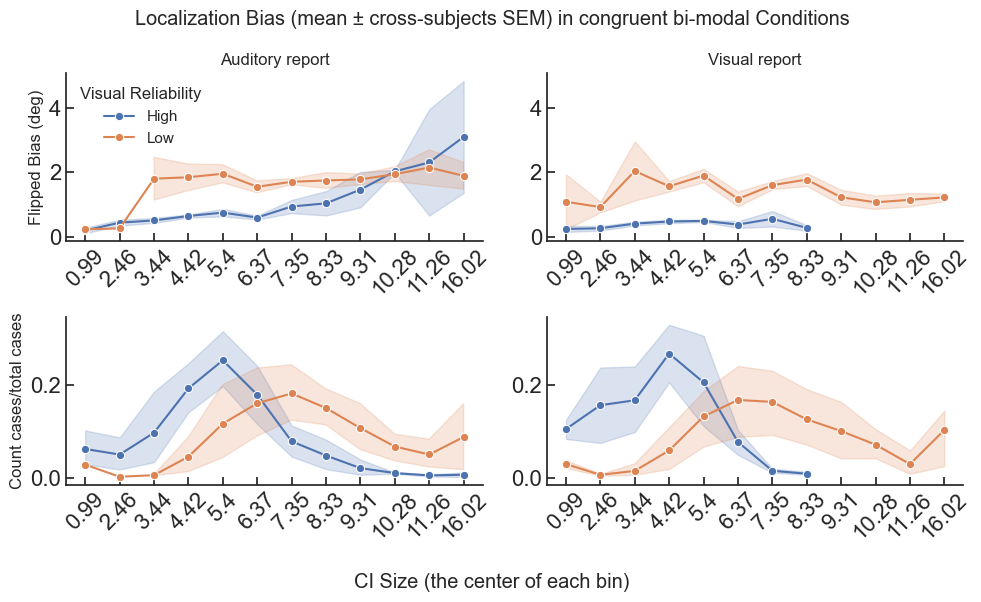

In [20]:
#plot
fig, axs = plt.subplots(2, 2, figsize=(10, 6))
# share y-axis within each row manually
for row in axs:
    row[1].sharey(row[0])  # share y between left and right subplot in the same row

# auditory
sns.lineplot(data=df_cong_avg_stim[(df_cong_avg_stim['Modality']=='A')], x='CI Bin', y='flipBias_mean', hue='vislab', errorbar='se', marker='o', ax = axs[0, 0])
# visual
sns.lineplot(data=df_cong_avg_stim[(df_cong_avg_stim['Modality']=='V')], x='CI Bin', y='flipBias_mean', hue='vislab', errorbar='se', marker='o', ax = axs[0, 1],legend=None)
# auditory
sns.lineplot(data=df_cong_avg_stim[(df_cong_avg_stim['Modality']=='A')], x='CI Bin', hue='vislab', y='count_reg', estimator='sum', marker='o', ax = axs[1,0],legend=None)
# visual
sns.lineplot(data=df_cong_avg_stim[(df_cong_avg_stim['Modality']=='V')], x='CI Bin', y='count_reg', hue='vislab', estimator='sum', marker='o', ax = axs[1,1],legend=None)

for ax in axs.flatten():
    clean_axs(ax)
    ax.set_xticks(range(len(ci_labels)))
    ax.set_xticklabels([round(x, 2) for x in ci_labels], rotation=45)
    ax.set_xlabel('')
    ax.set_ylabel('')
    #ax.legend('')
fig.supxlabel('CI Size (the center of each bin)')
axs[0,0].set_title('Auditory report')
axs[0,0].set_ylabel('Flipped Bias (deg)')
axs[0,1].set_title('Visual report')
axs[1,0].set_ylabel('Count cases/total cases')
axs[0,0].legend(title='Visual Reliability', frameon=False)
#axs[1].legend(title='Visual Reliability', frameon=False)
fig.suptitle('Localization Bias (mean ± cross-subjects SEM) in congruent bi-modal Conditions')
plt.tight_layout()
plt.show()

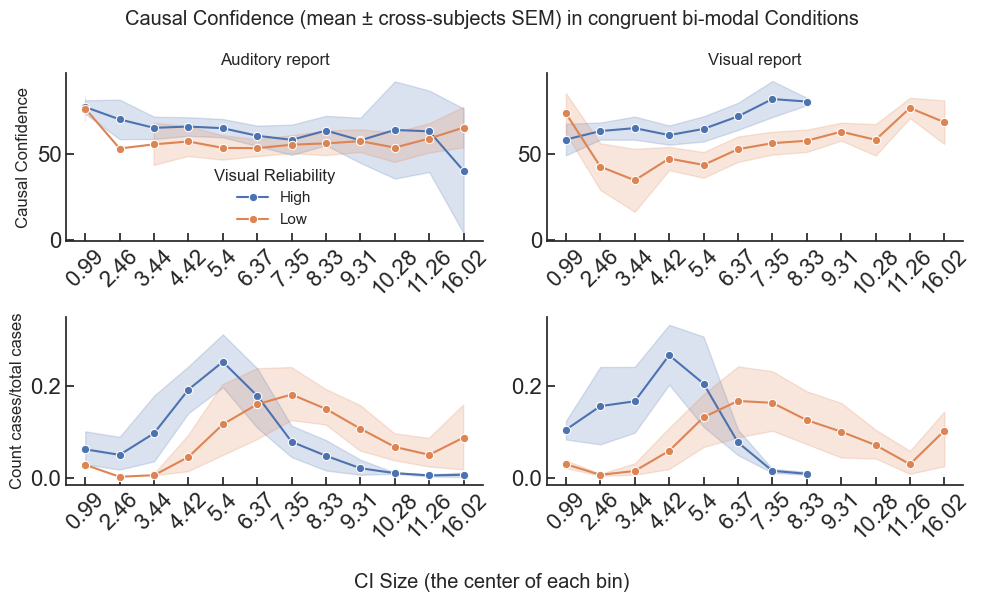

In [22]:
#plot
fig, axs = plt.subplots(2, 2, figsize=(10, 6))
# share y-axis within each row manually
for row in axs:
    row[1].sharey(row[0])  # share y between left and right subplot in the same row

# auditory
sns.lineplot(data=df_cong_avg_stim[(df_cong_avg_stim['Modality']=='A')], x='CI Bin', y='Conf Level_mean', hue='vislab', errorbar='se', marker='o', ax = axs[0, 0])
# visual
sns.lineplot(data=df_cong_avg_stim[(df_cong_avg_stim['Modality']=='V')], x='CI Bin', y='Conf Level_mean', hue='vislab', errorbar='se', marker='o', ax = axs[0, 1],legend=None)
# auditory
sns.lineplot(data=df_cong_avg_stim[(df_cong_avg_stim['Modality']=='A')], x='CI Bin', hue='vislab', y='count_reg', estimator='sum', marker='o', ax = axs[1,0],legend=None)
# visual
sns.lineplot(data=df_cong_avg_stim[(df_cong_avg_stim['Modality']=='V')], x='CI Bin', y='count_reg', hue='vislab', estimator='sum', marker='o', ax = axs[1,1],legend=None)

for ax in axs.flatten():
    clean_axs(ax)
    ax.set_xticks(range(len(ci_labels)))
    ax.set_xticklabels([round(x, 2) for x in ci_labels], rotation=45)
    ax.set_xlabel('')
    ax.set_ylabel('')
    #ax.legend(''
fig.supxlabel('CI Size (the center of each bin)')
axs[0,0].set_title('Auditory report')
axs[0,0].set_ylabel('Causal Confidence')
axs[0,1].set_title('Visual report')
axs[1,0].set_ylabel('Count cases/total cases')
axs[0,0].legend(title='Visual Reliability', frameon=False)
#axs[1].legend(title='Visual Reliability', frameon=False)
fig.suptitle('Causal Confidence (mean ± cross-subjects SEM) in congruent bi-modal Conditions')
plt.tight_layout()
plt.show()

# Unisensory conditions

In [23]:
df_uni = df.loc[(df['Vis Loc'].isna())|(df['Aud Loc'].isna())].copy().reset_index(drop=True)
df_uni.loc[df_uni.Modality=='A', 'Vis Rel'] = 0 # rewrite the visual reliability for unimodal auditory trials to 0

df_uni_stat = df_uni.groupby(['sub_id', 'Modality', 'Vis Rel', 'stim_loc'])['Resp Loc'].agg(['mean', 'std']).reset_index()
df_uni = pd.merge(df_uni, df_uni_stat, on=['sub_id', 'Modality', 'Vis Rel', 'stim_loc'], how='left')
df_uni['bias'] = (df_uni['Resp Loc'] - df_uni['mean']).abs()

df_uni_filter = (df_uni.groupby(['sub_id', 'Modality', 'Vis Rel', 'stim_loc'], group_keys=False)
                 .apply(remove_outliers)
                 .reset_index(drop=True))

df_uni_filter, ci_labels= get_cirange(df_uni_filter)

C:\Users\wenlou\AppData\Local\Temp\ipykernel_4116\1993563162.py:9: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(remove_outliers)


In [24]:
# two step average:
df_uni_avg = df_uni_filter.groupby(['sub_id', 'Modality', 'Vis Rel', 'stim_loc', 'CI Bin'])['bias'].agg(['mean', 'count']).reset_index()
df_uni_avg_stim = df_uni_avg.groupby(['sub_id', 'Modality', 'Vis Rel', 'CI Bin']).agg({'mean':'mean', 'count':'sum'}).reset_index()

sum_count = df_uni_avg_stim.groupby(['Modality', 'Vis Rel'], as_index=False)['count'].sum()
df_uni_avg_stim = pd.merge(df_uni_avg_stim, sum_count, on=['Modality', 'Vis Rel'], suffixes=('', '_total'))
df_uni_avg_stim['count_reg'] = df_uni_avg_stim['count'] / df_uni_avg_stim['count_total']   # convert to percentage
df_uni_avg_stim['vislab'] = df_uni_avg_stim['Vis Rel'].map({1:'High', 2:'Low'})
df_uni_avg_stim

,sub_id,Modality,Vis Rel,CI Bin,mean,count,count_total,count_reg,vislab
0,2,A,0,0,2.393773,12,2867,0.004186,NaN
1,2,A,0,1,1.386930,14,2867,0.004883,NaN
2,2,A,0,2,1.510648,17,2867,0.005930,NaN
3,2,A,0,3,1.844521,55,2867,0.019184,NaN
4,2,A,0,4,1.676251,73,2867,0.025462,NaN
...,...,...,...,...,...,...,...,...,...
197,25,V,2,7,1.123778,8,480,0.016667,Low
198,25,V,2,8,0.798958,7,480,0.014583,Low
199,25,V,2,9,0.962917,8,480,0.016667,Low
200,25,V,2,10,0.832083,7,480,0.014583,Low


C:\Users\wenlou\AppData\Local\Temp\ipykernel_4116\3476889467.py:28: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axs[0,0].legend(title='Visual Reliability', frameon=False)


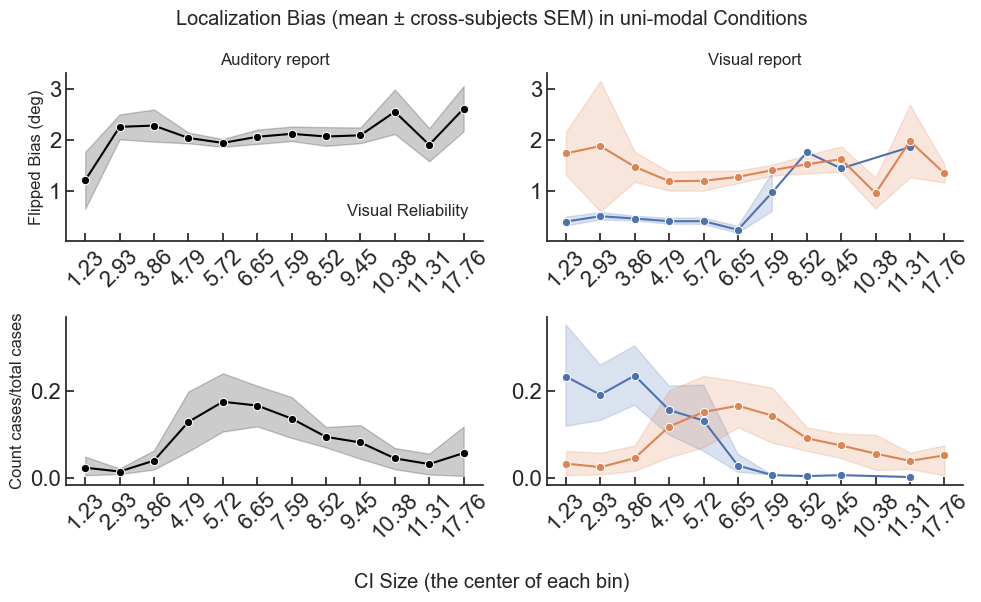

In [28]:
#plot
fig, axs = plt.subplots(2, 2, figsize=(10, 6))
# share y-axis within each row manually
for row in axs:
    row[1].sharey(row[0])  # share y between left and right subplot in the same row

# auditory
sns.lineplot(data=df_uni_avg_stim[(df_uni_avg_stim['Modality']=='A')], x='CI Bin', y='mean', color='black', errorbar='se', marker='o', ax = axs[0, 0])
# visual
sns.lineplot(data=df_uni_avg_stim[(df_uni_avg_stim['Modality']=='V')], x='CI Bin', y='mean', hue='vislab', errorbar='se', marker='o', ax = axs[0, 1],legend=None)
# auditory
sns.lineplot(data=df_uni_avg_stim[(df_uni_avg_stim['Modality']=='A')], x='CI Bin',  y='count_reg', color='black', estimator='sum', marker='o', ax = axs[1,0],legend=None)
# visual
sns.lineplot(data=df_uni_avg_stim[(df_uni_avg_stim['Modality']=='V')], x='CI Bin', y='count_reg', hue='vislab', estimator='sum', marker='o', ax = axs[1,1],legend=None)

for ax in axs.flatten():
    clean_axs(ax)
    ax.set_xticks(range(len(ci_labels)))
    ax.set_xticklabels([round(x, 2) for x in ci_labels], rotation=45)
    ax.set_xlabel('')
    ax.set_ylabel('')
    #ax.legend('')
fig.supxlabel('CI Size (the center of each bin)')
axs[0,0].set_title('Auditory report')
axs[0,0].set_ylabel('Flipped Bias (deg)')
axs[0,1].set_title('Visual report')
axs[1,0].set_ylabel('Count cases/total cases')
axs[0,0].legend(title='Visual Reliability', frameon=False)
#axs[1].legend(title='Visual Reliability', frameon=False)
fig.suptitle('Localization Bias (mean ± cross-subjects SEM) in uni-modal Conditions')
plt.tight_layout()
plt.show()

# For model simulation

In [2]:
from scripts.experiments import ModelEvaluator

device is : cpu


In [3]:
ev=ModelEvaluator('base_clamp')
m_lst = [1, 2]

In [4]:
df_sim = []
df_beh = []

# aggreagte all the subjects
for sub_id in ev.exp.sub_lst_all:
    for m_id in m_lst:
        df_sim_t = ev.get_model_prediction(m_id, sub_id, nsim=1000)
        df_sim_t['model_id'] = m_id
        df_sim.append(df_sim_t) 
        # load beh data differently??
        df_beh_t = ev.organize_dat(dat = ev.exp.get_beh_data(sub_id, MNLE=False),sub_id=sub_id)
        df_beh.append(df_beh_t)

df_sim = pd.concat(df_sim, ignore_index = True)
df_beh = pd.concat(df_beh, ignore_index = True)

m:\1confiProj\scripts\experiments.py:234: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(remove_outliers)
m:\1confiProj\scripts\experiments.py:234: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(remove_outliers)
m:\1confiProj\scripts\experiments.py:234: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping column

In [14]:
def get_cirange(df):
    # ci range
    ci_bins = np.append(0, np.linspace(df['CISize'].quantile(0.05), df['CISize'].quantile(0.95), 11))  # 10 bins
    ci_bins = np.append(ci_bins, df['CISize'].max()+0.1)  # ensure the max value is included
    df['CIBin'] = pd.cut(df['CISize'], bins=ci_bins, labels=False)
    ci_labels = [(ci_bins[i] + ci_bins[i+1]) / 2 for i in range(len(ci_bins)-1)]
    return df.copy(), ci_labels
df_cong_sim, ci_labels= get_cirange(df_sim.loc[(df_sim['AudLoc'] == df_sim['VisLoc'])&(df_sim.model_id==m_lst[0])].copy().reset_index(drop=True))

In [8]:
df_cong_sim

,AudLoc,VisLoc,VisRel,blockType,RespLoc,CISize,Sources,ConfLevel,sub_id,delta_VA,...,Modality,mean,std,bias,flipBias,abs_delta_VA,bias_zscore,CISize_zscore,model_id,CIBin
0,-10.0,-10.0,1.0,1.0,-5.969913,11.804980,2.0,49.0,2,0.0,...,A,-8.092806,2.799827,2.122892,2.122892,0.0,0.758223,1.898979,1,11
1,-10.0,-10.0,1.0,1.0,-6.252999,3.762953,1.0,66.0,2,0.0,...,A,-8.092806,2.799827,1.839807,1.839807,0.0,0.657114,-0.847611,1,2
2,-10.0,-10.0,1.0,1.0,-9.149222,2.725612,1.0,68.0,2,0.0,...,A,-8.092806,2.799827,-1.056417,-1.056417,0.0,-0.377315,-1.201893,1,1
3,-10.0,-10.0,1.0,1.0,-8.205441,5.005536,1.0,42.0,2,0.0,...,A,-8.092806,2.799827,-0.112635,-0.112635,0.0,-0.040229,-0.423232,1,4
4,-10.0,-10.0,1.0,1.0,-8.159634,3.677334,1.0,36.0,2,0.0,...,A,-8.092806,2.799827,-0.066828,-0.066828,0.0,-0.023868,-0.876852,1,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
317682,10.0,10.0,2.0,0.0,4.378542,7.093340,1.0,59.0,25,0.0,...,V,6.521103,3.162634,-2.142561,-2.142561,0.0,-0.677461,-0.307497,2,6
317683,10.0,10.0,2.0,0.0,8.520300,14.169998,1.0,70.0,25,0.0,...,V,6.521103,3.162634,1.999197,1.999197,0.0,0.632130,2.088286,2,11
317684,10.0,10.0,2.0,0.0,0.806569,10.902569,1.0,97.0,25,0.0,...,V,6.521103,3.162634,-5.714534,-5.714534,0.0,-1.806890,0.982107,2,11
317685,10.0,10.0,2.0,0.0,2.771757,7.690946,1.0,100.0,25,0.0,...,V,6.521103,3.162634,-3.749346,-3.749346,0.0,-1.185514,-0.105179,2,7


In [15]:
df_cong_sim.loc[df_cong_sim.Modality=='A','stim_loc'] = df_cong_sim.loc[df_cong_sim.Modality=='A', 'AudLoc']
df_cong_sim.loc[df_cong_sim.Modality=='V','stim_loc'] = df_cong_sim.loc[df_cong_sim.Modality=='V', 'VisLoc']

In [16]:
# two step average:
# sources and the causal coonfidence
df_cong_avg = df_cong_sim.groupby(['sub_id', 'Modality', 'VisRelLabel', 'stim_loc','CIBin'], as_index=False).agg({'flipBias':['mean', 'count'], 'ConfLevel':'mean'}).reset_index()
df_cong_avg.columns = ['_'.join(col).strip() if col[1] else col[0] for col in df_cong_avg.columns.values]
#df_cong_avg_stim = df_cong_avg.copy()
# select the delta_VA >0
#df_incong_avg = df_incong_avg.loc[df_incong_avg['delta_VA']>0].copy().reset_index(drop=True)
# average the stims
df_cong_avg_stim = df_cong_avg.groupby(['sub_id', 'Modality', 'VisRelLabel', 'CIBin']).agg({'flipBias_mean':'mean', 'flipBias_count':'sum', 'ConfLevel_mean':'mean'}).reset_index()

# normalize the count to percentage
sum_count = df_cong_avg_stim.groupby(['Modality', 'VisRelLabel'], as_index=False)['flipBias_count'].sum()
df_cong_avg_stim = pd.merge(df_cong_avg_stim, sum_count, on=['Modality', 'VisRelLabel'], suffixes=('', '_total'))
df_cong_avg_stim['count_reg'] = df_cong_avg_stim['flipBias_count'] / df_cong_avg_stim['flipBias_count_total']   # convert to percentage

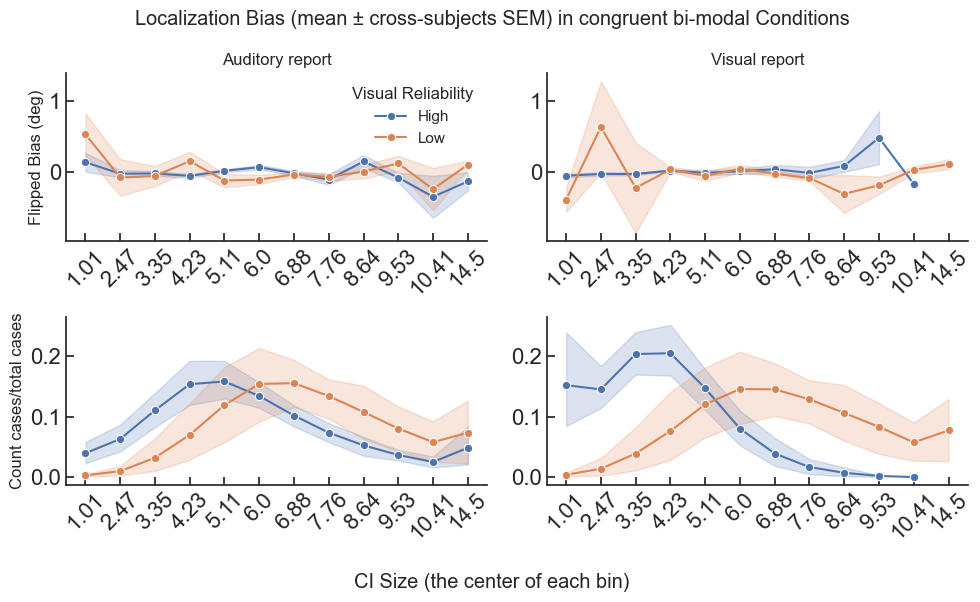

In [17]:
#plot
fig, axs = plt.subplots(2, 2, figsize=(10, 6))
# share y-axis within each row manually
for row in axs:
    row[1].sharey(row[0])  # share y between left and right subplot in the same row

# auditory
sns.lineplot(data=df_cong_avg_stim[(df_cong_avg_stim['Modality']=='A')], x='CIBin', y='flipBias_mean', hue='VisRelLabel', errorbar='se', marker='o', ax = axs[0, 0])
# visual
sns.lineplot(data=df_cong_avg_stim[(df_cong_avg_stim['Modality']=='V')], x='CIBin', y='flipBias_mean', hue='VisRelLabel', errorbar='se', marker='o', ax = axs[0, 1],legend=None)
# auditory
sns.lineplot(data=df_cong_avg_stim[(df_cong_avg_stim['Modality']=='A')], x='CIBin', hue='VisRelLabel', y='count_reg', estimator='sum', marker='o', ax = axs[1,0],legend=None)
# visual
sns.lineplot(data=df_cong_avg_stim[(df_cong_avg_stim['Modality']=='V')], x='CIBin', y='count_reg', hue='VisRelLabel', estimator='sum', marker='o', ax = axs[1,1],legend=None)

for ax in axs.flatten():
    clean_axs(ax)
    ax.set_xticks(range(len(ci_labels)))
    ax.set_xticklabels([round(x, 2) for x in ci_labels], rotation=45)
    ax.set_xlabel('')
    ax.set_ylabel('')
    #ax.legend('')
fig.supxlabel('CI Size (the center of each bin)')
axs[0,0].set_title('Auditory report')
axs[0,0].set_ylabel('Flipped Bias (deg)')
axs[0,1].set_title('Visual report')
axs[1,0].set_ylabel('Count cases/total cases')
axs[0,0].legend(title='Visual Reliability', frameon=False)
#axs[1].legend(title='Visual Reliability', frameon=False)
fig.suptitle('Localization Bias (mean ± cross-subjects SEM) in congruent bi-modal Conditions')
plt.tight_layout()
plt.show()